## LHb-DA correlation

## Setup

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.io
import h5py
import os
import tqdm
import mat73

import pyNeuroDAP as ndap

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


(199749,)
(199749,)


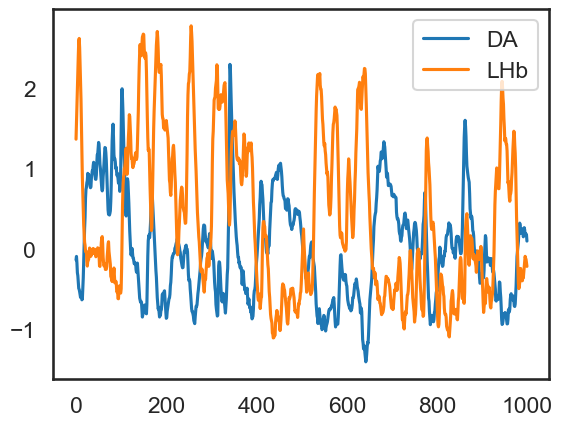

In [27]:
root_dir = '/Users/shunli/Projects/pyNeuroDAP/Data/20250831-SL389-Reward1_g0/'
data_file_path = os.path.join(root_dir, 'timeseries_20250831-SL389-Reward1_g0.mat')

# Load the MATLAB file
data_mat = ndap.load_mat(data_file_path)

# Extract the data from the matlab file
DA = data_mat['timeSeries']['data'][0][1:]
LHb = data_mat['timeSeries']['data'][1][1:]

print(DA.shape)
print(LHb.shape)

# Plot the first 1000 data points of both signals
plt.plot(DA[:1000])
plt.plot(LHb[:1000])
plt.legend(['DA', 'LHb'])
plt.show()

Peak @ -73 samples = -1460.0 ms
Trough @ 9 samples = 180.0 ms


/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_4125/2562741000.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{t*ms_per_sample:.0f}" for t in xticks])


Text(0.5, 0, 'Lag (ms)')

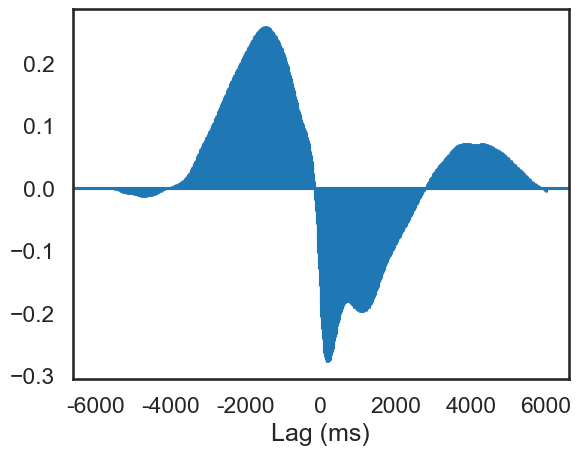

In [57]:
# Xcorr between LHb and derivative of DA
Fs = data_mat['timeSeries']['finalFs'][0]
lags, c, _, _ = plt.xcorr(DA, LHb, maxlags=300)

ms_per_sample = 1000.0 / Fs
peak_lag = lags[c.argmax()]
trough_lag = lags[c.argmin()]

print(f"Peak @ {peak_lag} samples = {peak_lag*ms_per_sample:.1f} ms")
print(f"Trough @ {trough_lag} samples = {trough_lag*ms_per_sample:.1f} ms")

# (Optional) show the x-axis in milliseconds instead of samples
ax = plt.gca()
xticks = ax.get_xticks()
ax.set_xticklabels([f"{t*ms_per_sample:.0f}" for t in xticks])
ax.set_xlabel("Lag (ms)")



Peak @ -7 samples = -140.0 ms
Trough @ 2 samples = 40.0 ms


/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_4125/341990290.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{t*ms_per_sample:.0f}" for t in xticks])


(-100.0, 100.0)

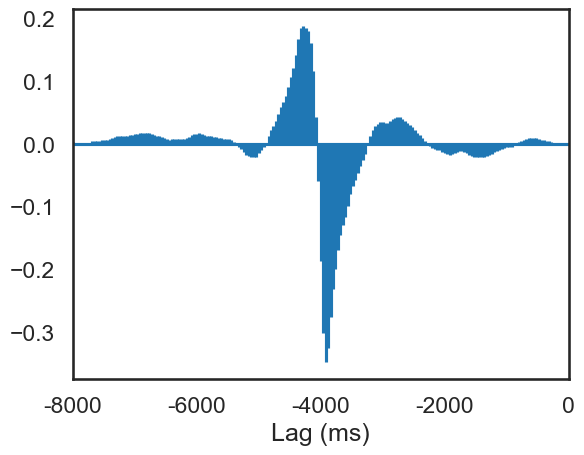

In [59]:
# Xcorr between LHb and derivative of DA
DA_deriv = np.gradient(DA)
LHb_deriv = np.gradient(LHb)
Fs = data_mat['timeSeries']['finalFs'][0]
lags, c, _, _ = plt.xcorr(DA_deriv, LHb_deriv, maxlags=300)

ms_per_sample = 1000.0 / Fs
peak_lag = lags[c.argmax()]
trough_lag = lags[c.argmin()]

print(f"Peak @ {peak_lag} samples = {peak_lag*ms_per_sample:.1f} ms")
print(f"Trough @ {trough_lag} samples = {trough_lag*ms_per_sample:.1f} ms")

# (Optional) show the x-axis in milliseconds instead of samples
ax = plt.gca()
xticks = ax.get_xticks()
ax.set_xticklabels([f"{t*ms_per_sample:.0f}" for t in xticks])
ax.set_xlabel("Lag (ms)")
ax.set_xlim(-100, 100)